#  Feature Matching Across Photos  

### Import the Required Libraries

In [1]:
import cv2
import matplotlib.pyplot as plt

### Load Images

In [10]:
image1 = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Object.png")
image2 = cv2.imread("Documents/AIML-Assessment/Module-2/raw_captures/Angled_Object.png")
image1_gray = cv2.cvtColor(image1,cv2.COLOR_BGR2GRAY)
image2_gray = cv2.cvtColor(image2,cv2.COLOR_BGR2GRAY)

### Detect ORB Features

In [11]:
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(image1_gray,None)
keypoints2, descriptors2 = orb.detectAndCompute(image2_gray,None)

In [12]:
image1_display = cv2.drawKeypoints(image1, keypoints=keypoints1, outImage=None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image2_display = cv2.drawKeypoints(image2, keypoints=keypoints2, outImage=None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

(np.float64(-0.5), np.float64(1447.5), np.float64(1085.5), np.float64(-0.5))

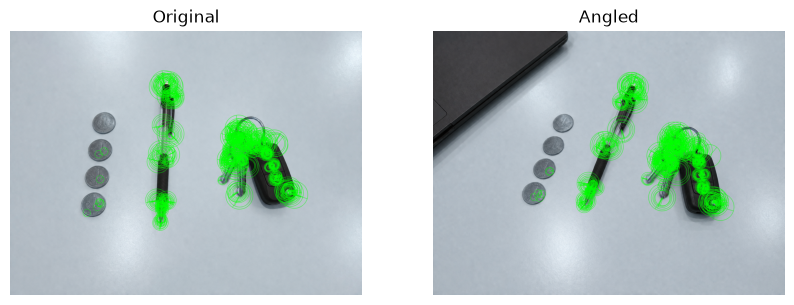

In [13]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(image1_display)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(image2_display)
axes[1].set_title("Angled")
axes[1].axis('off')

### Feature Matching

In [15]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(descriptors1,descriptors2))
matches.sort(key=lambda x:x.distance, reverse=False)

### Good Matches

In [23]:
good_matches = [m for m in matches if m.distance < 40]
print("Good matches:", len(good_matches))

Good matches: 60


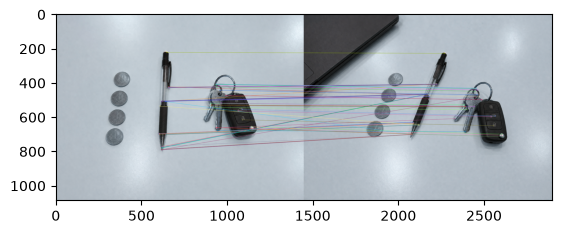

In [24]:
matched_img = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(matched_img)

###  Report
ORB feature matching found 60 good matches, and the keychain produced the strongest match across the two photos.